In [1]:
import pandas as pd               # tables / DataFrames - the core data tool
import numpy as np                # numeric helpers
import matplotlib.pyplot as plt   # plotting engine
import seaborn as sns             # prettier statistical plots on top of matplotlib

In [2]:
sns.set_theme(style="whitegrid")  # clean default look for all charts


In [7]:
ECOM = "Ecommerce Purchases1.csv"
SUI  = "ADU_SUI_DATASET.csv"
OUT  = "outputs"

In [8]:

print("=" * 70)
print("QUESTION 4a  -  ECOMMERCE PURCHASES ANALYSIS")
print("=" * 70)

# Read the CSV into a DataFrame (a table with rows and named columns)
df = pd.read_csv(ECOM)
print("Rows, Columns:", df.shape)


QUESTION 4a  -  ECOMMERCE PURCHASES ANALYSIS
Rows, Columns: (1000, 14)


In [9]:

# ---- 4a.1  Transactions with Purchase Price above 90 --------------------------
# df['Purchase Price'] > 90  builds a True/False mask; summing it counts the Trues
high = df[df["Purchase Price"] > 90]
print("\n[1] Purchase Price > 90  ->  count =", len(high))



[1] Purchase Price > 90  ->  count = 106


In [10]:
# ---- 4a.2  Extract email domain and count unique domains ----------------------
# .str.split('@') splits each email at '@'; .str[1] takes the part AFTER the '@'
df["Domain"] = df["Email"].str.split("@").str[1]
print("[2] Unique email domains =", df["Domain"].nunique())
print("    domains:", sorted(df["Domain"].unique()))

[2] Unique email domains = 10
    domains: ['aol.com', 'company.com', 'gmail.com', 'hotmail.com', 'icloud.com', 'live.com', 'mail.com', 'outlook.com', 'protonmail.com', 'yahoo.com']


In [11]:
# ---- 4a.3  Average Purchase Price for each Language ---------------------------
# groupby gathers rows sharing a Language, then we average Purchase Price in each
avg_lang = df.groupby("Language")["Purchase Price"].mean().round(2)
print("\n[3] Average Purchase Price by Language:")
print(avg_lang.to_string())



[3] Average Purchase Price by Language:
Language
de    54.06
el    51.67
en    51.45
es    54.34
fr    49.03
it    47.00
ja    52.04
pt    48.29
ru    54.56
zh    56.86


In [12]:

# ---- 4a.4  Top 5 transactions by Purchase Price + their Job titles ------------
top5 = df.nlargest(5, "Purchase Price")[["Purchase Price", "Job"]]
print("\n[4] Top 5 highest Purchase Prices and Jobs:")
print(top5.to_string(index=False))


[4] Top 5 highest Purchase Prices and Jobs:
 Purchase Price                          Job
          99.97 Engineer, civil (consulting)
          99.91                         Chef
          99.84 Engineer, civil (consulting)
          99.65        Accountant, chartered
          99.59          Production engineer


In [13]:
# ---- 4a.5  Customers using Mastercard AND Purchase Price > 50 -----------------
# Two conditions joined with & (and). Each condition is wrapped in ( ).
mc = df[(df["CC Provider"] == "Mastercard") & (df["Purchase Price"] > 50)]
print("\n[5] Mastercard & price > 50  ->  count =", len(mc))


[5] Mastercard & price > 50  ->  count = 115


In [14]:
# ---- 4a.6  Credit cards that expire in 2025 -----------------------------------
# Exp date looks like 'MM/YY'. Take the YY (last 2 chars) and compare to '25'.
df["ExpYear"] = df["CC Exp Date"].str.split("/").str[1]
expire_2025 = df[df["ExpYear"] == "25"]
print("[6] Cards expiring in 2025  ->  count =", len(expire_2025))

[6] Cards expiring in 2025  ->  count = 229


In [15]:
# ---- 4a.7  Total revenue from purchases made in the AM period -----------------
am_revenue = df[df["AM or PM"] == "AM"]["Purchase Price"].sum()
print("\n[7] Total AM revenue = Rs.", round(am_revenue, 2))



[7] Total AM revenue = Rs. 25369.25


In [16]:
# ---- 4a.8  Transaction with the single highest Purchase Price -----------------
# idxmax() returns the row LABEL of the maximum value; .loc fetches that whole row
top_row = df.loc[df["Purchase Price"].idxmax()]
print("\n[8] Highest-value transaction (all details):")
print(top_row.to_string())


[8] Highest-value transaction (all details):
Address                                       6806 Moore St, City 413
Lot                                                              4 cc
AM or PM                                                           PM
Browser Info        Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
Company                                                   Davis Group
Credit Card                                          3313180140836120
CC Exp Date                                                     01/25
CC Security Code                                                 5362
CC Provider                                              JCB 16 digit
Email                                     william.martin413@gmail.com
Job                                      Engineer, civil (consulting)
IP Address                                             126.12.102.211
Language                                                           en
Purchase Price                              

In [17]:
# ---- 4a.9  en  AND  price 50-80  AND  Visa 16 digit ---------------------------
q9 = df[(df["Language"] == "en") &
        (df["Purchase Price"].between(50, 80)) &
        (df["CC Provider"] == "Visa 16 digit")]
print("\n[9] en + price 50-80 + Visa 16 digit  ->  count =", len(q9))


[9] en + price 50-80 + Visa 16 digit  ->  count = 34


In [18]:

print("\n" + "=" * 70)
print("QUESTION 4b  -  ADULT SUICIDE DATASET ANALYSIS")
print("=" * 70)



QUESTION 4b  -  ADULT SUICIDE DATASET ANALYSIS


In [19]:
sdf = pd.read_csv(SUI)
print("Before cleaning:", sdf.shape, "| nulls:", int(sdf.isnull().sum().sum()))

Before cleaning: (720, 7) | nulls: 25


In [20]:
# ---- 4b.1  Remove nulls, then % of Male vs Female suicides --------------------
sdf = sdf.dropna()                      # drop any row containing a missing value
print("After  cleaning:", sdf.shape)

by_gender = sdf.groupby("Gender")["suicides_no"].sum()   # total suicides per gender
total = by_gender.sum()
pct = (by_gender / total * 100).round(2)                 # convert to percentages
print("\n[1] Suicide percentage by gender:")
print(pct.to_string())


After  cleaning: (695, 7)

[1] Suicide percentage by gender:
Gender
Female    24.11
Male      75.89


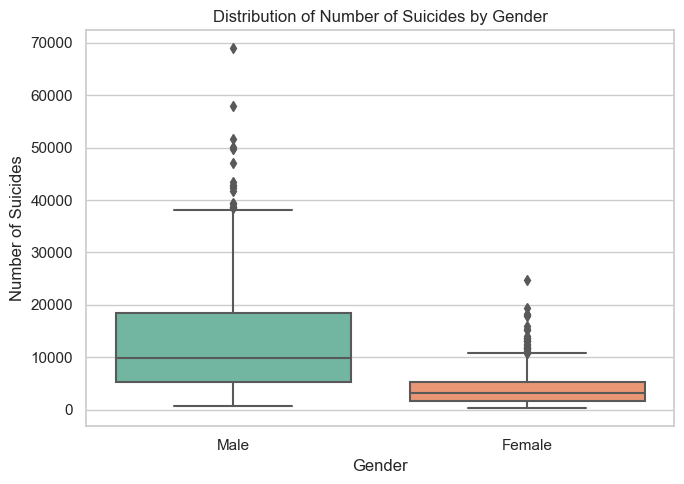

In [26]:
# ---- 4b.2  Box plot: Gender vs number of suicides -----------------------------
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=sdf,
    x="Gender",
    y="suicides_no",
    palette="Set2"
)

plt.title("Distribution of Number of Suicides by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Suicides")

plt.tight_layout()
plt.show()

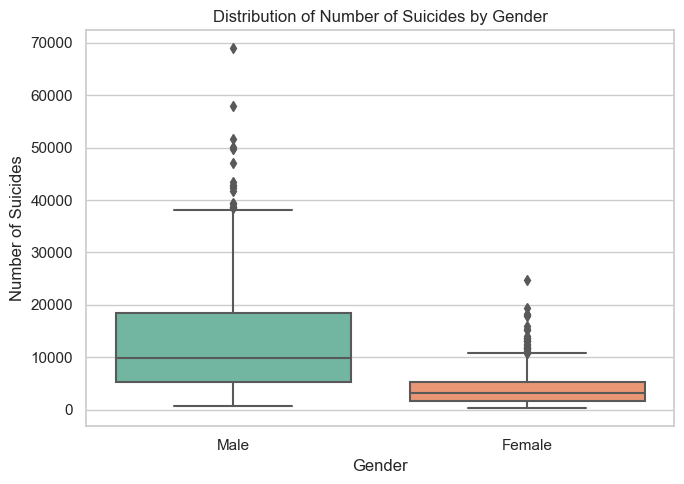

In [27]:
# ---- 4b.3  Violin plot: Gender vs population ----------------------------------
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=sdf,
    x="Gender",
    y="suicides_no",
    palette="Set2"
)

plt.title("Distribution of Number of Suicides by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Suicides")

plt.tight_layout()
plt.show()

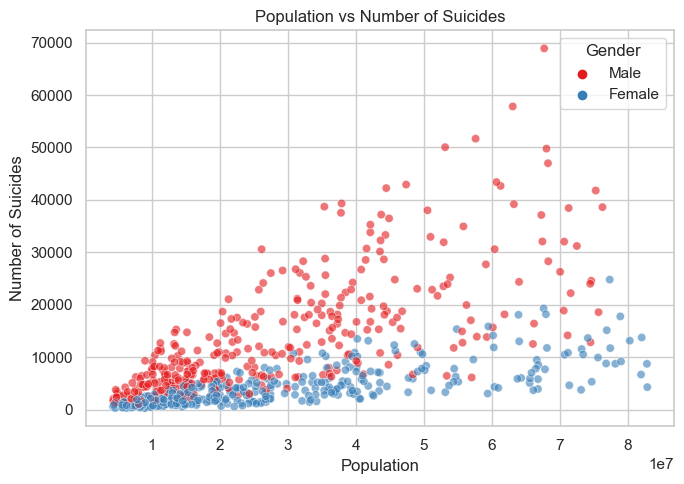

In [30]:
# ---- 4b.4  Scatter plot: population vs suicides_no ----------------------------
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=sdf,
    x="population",
    y="suicides_no",
    hue="Gender",
    alpha=0.6,
    palette="Set1"
)

plt.title("Population vs Number of Suicides")
plt.xlabel("Population")
plt.ylabel("Number of Suicides")

plt.tight_layout()
plt.show()

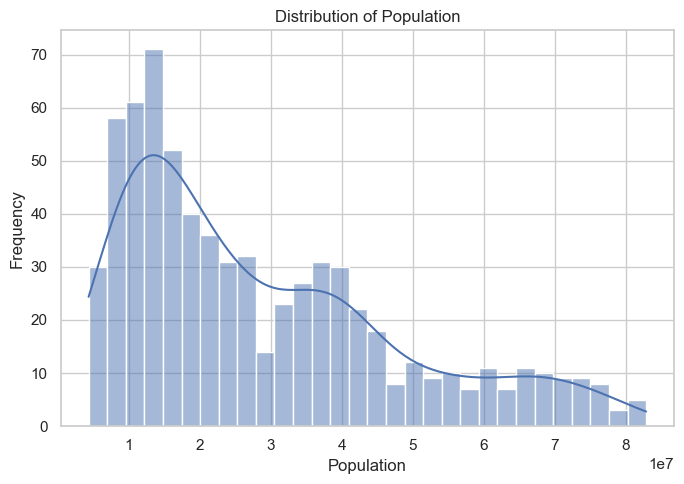

In [31]:
# ---- 4b.5  Histogram of population --------------------------------------------
plt.figure(figsize=(7, 5))

sns.histplot(
    sdf["population"],
    bins=30,
    kde=True,
    color="#4C72B0"
)

plt.title("Distribution of Population")
plt.xlabel("Population")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()